# 03 - Modeling & Evaluation

## Give Me Some Credit - Loan Default Prediction
The goal of this notebook is to compare a logistic regression baseline against tree-based models (Random Forest, XGBoost), handle the class imbalance confirmed in EDA (6.68% positive rate), and pick a final model based on metrics that actually matter for this problem - not accuracy. </br>
**Why not accuracy:** predicting "no default" for every single applicant gets ~93% accuracy for free, given the imbalance. That number would look great and mean nothing. Instead this notebook tracks:
* ROC-AUC: overall ranking quality across all thresholds
* PR-AUC (average precision): more informative than ROC-AUC under heavy imbalance, since it focuses on how well the model does on the minority (positive) class specifically
* Precision/recall/F1 at a chosen threshold: the operational numbers a lender would actually care about

In [1]:
import sys
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path('..') / "src"))
from pipeline import (
    ALL_FEATURES,
    CATEGORICAL_FEATURES,
    LOGISTIC_REGRESSION_NUMERIC_FEATURES,
    TARGET,
    build_full_pipeline,
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 1. Load processed data
Output of `02_cleaning_feature_engineering.ipynb`: already cleaned, imputed, capped, and feature engineered. 15 feature columns, stratified 80/20 split, 6.68% positive rate preserved in both splits

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")

print("Train:", train_df.shape, "Val:", val_df.shape)
print("Train positive rate:", train_df[TARGET].mean().round(4))
print("Val positive rate:", val_df[TARGET].mean().round(4))

Train: (119999, 16) Val: (30000, 16)
Train positive rate: 0.0668
Val positive rate: 0.0668


In [3]:
X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_val, y_val = val_df[ALL_FEATURES], val_df[TARGET]

## 2. Evaluation helper
One function used for every model so comparisons are apples-to-apples

In [4]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

results = {}

def evaluate(name, pipeline, X_val, y_val, threshold=0.5):
    proba = pipeline.predict_proba(X_val)[:, 1]      # continuous — for roc_auc_score, average_precision_score
    pred = (proba >= threshold).astype(int)
    metrics = {
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
    }
    results[name] = metrics

    print(f"---{name}---")
    for k,v in metrics.items():
        print(f"{k}: {v:.4f}")
    cm = confusion_matrix(y_val, pred)
    print('\nConfusion matrix (rows=actual, cols=predicted):')
    print(pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1']))

    return proba, pred

## 3. Baseline Logistic Regression
Uses `LOGISTIC_REGRESSION_NUMERIC_FEATURES`, which drops the three raw "times late" columns (0.98-0.99 correlated with each other per EDA) and keeps only the engineered `TotalTimesLate` - logistic regression is sensitive to multicollinearity in a way tree-based models arent.
`class_weight = "balanced"` reweights the loss to account for the 6.68% imbalance rather than training on raw counts.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_logreg_pipeline(model):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, LOGISTIC_REGRESSION_NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

logreg_features = LOGISTIC_REGRESSION_NUMERIC_FEATURES + CATEGORICAL_FEATURES
logreg_pipeline = build_logreg_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
)
logreg_pipeline.fit(X_train[logreg_features], y_train)

_ = evaluate("Logistic Regression", logreg_pipeline, X_val[logreg_features], y_val)

---Logistic Regression---
roc_auc: 0.8582
pr_auc: 0.3724
precision: 0.2111
recall: 0.7561
f1: 0.3300

Confusion matrix (rows=actual, cols=predicted):
          pred_0  pred_1
actual_0   22329    5666
actual_1     489    1516


## 4. Random Forest
Uses the full feature set (`ALL_FEATURES`) since tree models don't need multicollinearity handling. `class_weight='balanced'` again for the imbalance, as a first pass before trying SMOTE below.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = build_full_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )
)
rf_pipeline.fit(X_train, y_train)

_ = evaluate("Random Forest (class_weight)", rf_pipeline, X_val, y_val)

---Random Forest (class_weight)---
roc_auc: 0.8645
pr_auc: 0.3768
precision: 0.2422
recall: 0.7262
f1: 0.3633

Confusion matrix (rows=actual, cols=predicted):
          pred_0  pred_1
actual_0   23440    4555
actual_1     549    1456


## 5. XGBoost
Uses `scale_pos_weight` (XGBoost's equivalent of class balancing) set to the negative/positive class ratio from training set.

In [9]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_pipeline = build_full_pipeline(
    XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
    )
)
xgb_pipeline.fit(X_train, y_train)
_ = evaluate("XGBoost (scale_pos_weight)", xgb_pipeline, X_val, y_val)

scale_pos_weight: 13.96
---XGBoost (scale_pos_weight)---
roc_auc: 0.8682
pr_auc: 0.3944
precision: 0.2245
recall: 0.7756
f1: 0.3482

Confusion matrix (rows=actual, cols=predicted):
          pred_0  pred_1
actual_0   22624    5371
actual_1     450    1555


## 6. Imbalance handling: class weighting vs. SMOTE
Class weighting (used above) reweights the loss function but trains on the original data distribution. SMOTE instead synthesizes new minority-class examples to literally rebalance the training set. Worth comparing directly on the same model (Random Forest) to see whether it's actually worth the added capacity; SMOTE isn't free, it can overfit to synthetic patterns in the minority class. </br>
**Important:** SMOTE must only be applied to the training set, never to validation, otherwise synthetic points leak information and inflate the validation metrics artifically.

In [11]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from pipeline import build_preprocessing_pipeline

rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', build_preprocessing_pipeline()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    )),
])
rf_smote_pipeline.fit(X_train, y_train)

_ = evaluate("Random Forest (SMOTE)", rf_smote_pipeline, X_val, y_val)

---Random Forest (SMOTE)---
roc_auc: 0.8642
pr_auc: 0.3855
precision: 0.2395
recall: 0.7297
f1: 0.3607

Confusion matrix (rows=actual, cols=predicted):
          pred_0  pred_1
actual_0   23350    4645
actual_1     542    1463


The Random Forest (class_weight) vs. Random Forest (SMOTE) the ROC-AUC values are close (0.8642 for SMOTE vs. 0.8645 for class_weight). The precision in the SMOTE model is slightly higher than class_weight, however the recall in class_weight is higher than SMOTE. The SMOTE model was overall better able to predict users who defaulted on their loans better than the class_weight. 

## 7. Model comparison table

In [12]:
comparison_df = pd.DataFrame(results).T.sort_values("pr_auc", ascending=False)
comparison_df.round(4)

,roc_auc,pr_auc,precision,recall,f1
XGBoost (scale_pos_weight),0.8682,0.3944,0.2245,0.7756,0.3482
Random Forest (SMOTE),0.8642,0.3855,0.2395,0.7297,0.3607
Random Forest (class_weight),0.8645,0.3768,0.2422,0.7262,0.3633
Logistic Regression,0.8582,0.3724,0.2111,0.7561,0.3300


## 8. ROC and Precision-Recall curves for the leading models
Curves show performance across all thresholds, not just the default 0.5 used above; useful since the "right" threshold for a lender depends on the actual cost of a missed default vs. a rejected good borrower, which isn't something this notebook can decide on its own

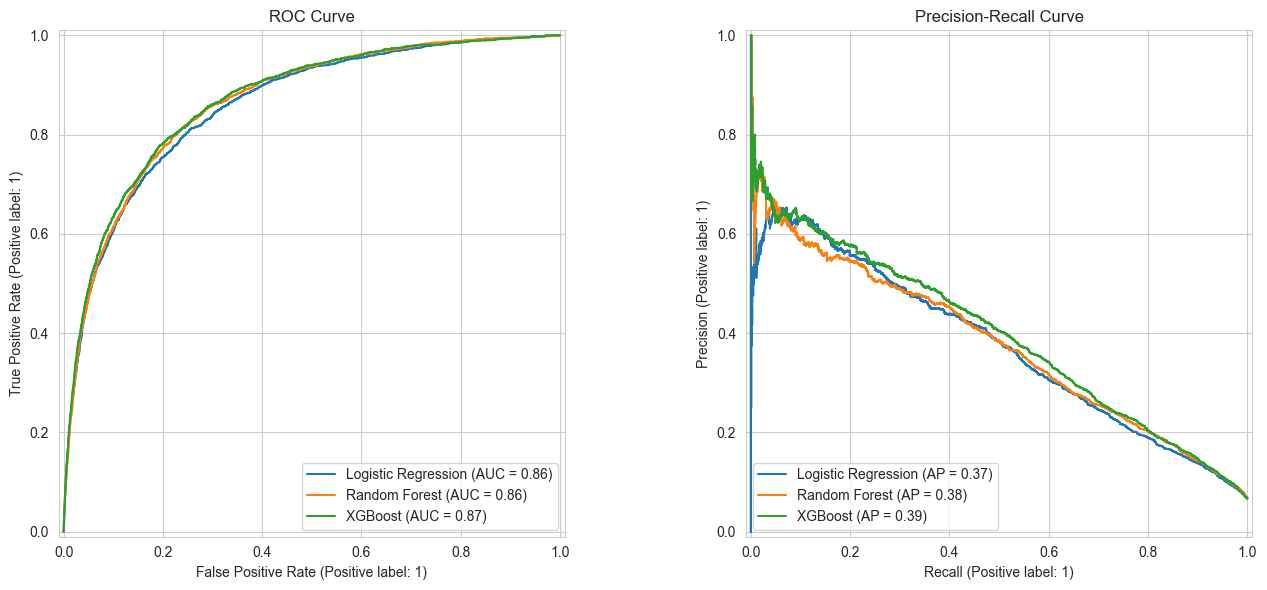

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, pipeline, X in [
    ("Logistic Regression", logreg_pipeline, X_val[logreg_features]),
    ("Random Forest", rf_pipeline, X_val),
    ('XGBoost', xgb_pipeline, X_val),
]:
    RocCurveDisplay.from_estimator(pipeline, X, y_val, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipeline, X, y_val, ax=axes[1], name=name)

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## 9. Pick the final model
Based on the comparison table and curves above, I will be using the XGBoost model; this model has the highest PR-AUC at 0.39, which is the more informative metric here given the class imbalance. Which the XGBoost had the best PR-AUC, the Random Forest model is close and trains faster.

In [14]:
final_pipeline = xgb_pipeline
final_model_name = "XGBoost"

import joblib
joblib.dump(final_pipeline, "../models/model.joblib")
print(f"Saved {final_model_name} to models/model.joblib")

Saved XGBoost to models/model.joblib


## 10. Summary
In summary, the final model chosen to predict loan defaulting was the XGBoost model; with ROC-AUC of 0.87 and the PR-AUC of 0.39, and an F1 score of 0.348. At Threshold of 0.3 the model catches more true defaulters at the cost of more false positives, which may be worth it if the cost of a missed default outweighs the cost of extra manual rev